In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')
from utils.utils import load_config
from core.rsa import get_rsa_matrix, get_model_rdm

config_file = "../configs/order_hippocampus.yaml"
config = load_config(config_file)

In [2]:
subs = [
                'sub-P10',
                'sub-P12',
                'sub-P13',
                'sub-P14',
                'sub-P15',
                'sub-P16',
                'sub-P17',
                'sub-P18',
                'sub-P19',
            #    'sub-P20', Unattentive
                'sub-P21',
                'sub-P22',
                'sub-P23', 
                'sub-P25',   
        # #        'sub-P26', missing event file
        #         'sub-P27',
        # #        'sub-P30', incomplete data
                'sub-P31',
                'sub-P34',
                'sub-P35',
                'sub-P36',
                'sub-P37',
                'sub-P41',
                'sub-P42',
                'sub-P43',
                'sub-P44',
                'sub-P45',
                'sub-P47',
                'sub-P48',
        # #        'sub-P49',   Unattentive
                'sub-P50', 
                'sub-P51', 
                ]

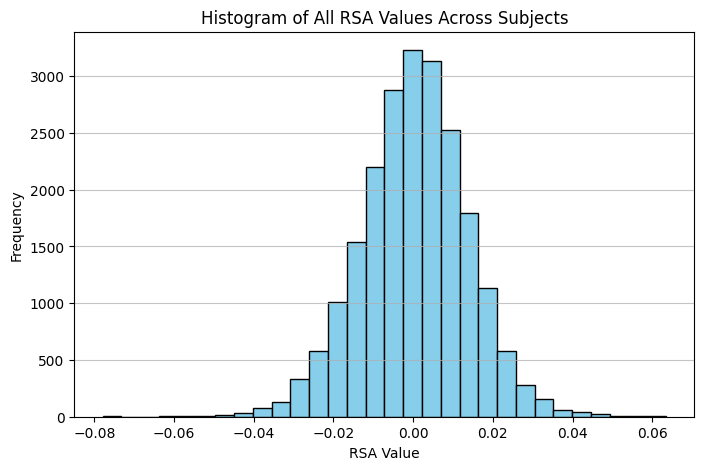

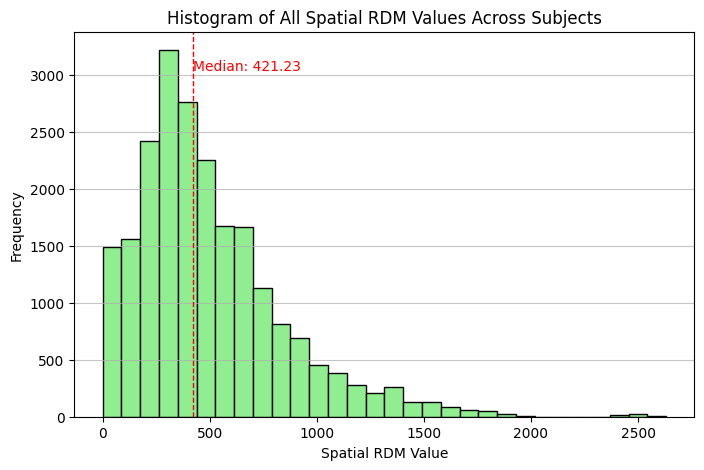

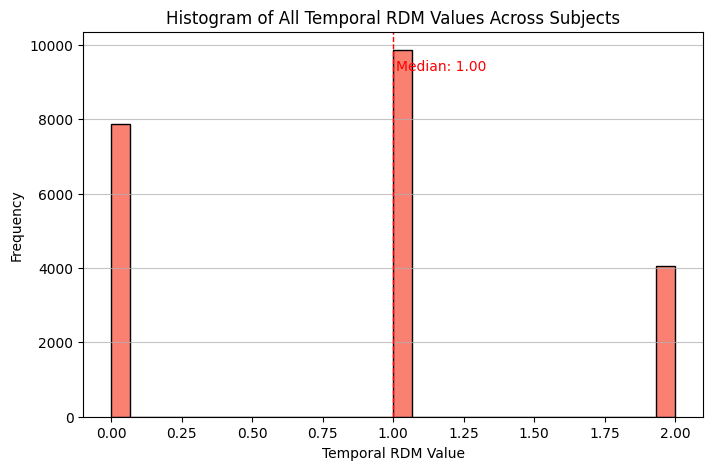

In [3]:
rsas = {}
spatial_rdms = {}
temporal_rdms = {}
# --- Run RSA per subject
for sub in subs:
    rep = 'all_reps'
    pre_rsa = get_rsa_matrix(sub, config=config, config_file=config_file, run_label='pre-post', rep=rep)
    spatial_rdm = get_model_rdm(sub=sub, config=config, config_file=config_file, spatial=True)
    temporal_rdm = get_model_rdm(sub=sub, config=config, config_file=config_file, spatial=False)


    rsas[sub] = pre_rsa
    spatial_rdms[sub] = spatial_rdm
    temporal_rdms[sub] = temporal_rdm
    




# plot historgram of all rsa values
all_rsa_values = np.concatenate([rsas[sub][np.triu_indices_from(rsas[sub], k=1)] for sub in subs])
plt.figure(figsize=(8, 5))
plt.hist(all_rsa_values, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of All RSA Values Across Subjects')
plt.xlabel('RSA Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# plot histogram of all spatial rdm values
all_spatial_rdm_values = np.concatenate([spatial_rdms[sub][np.triu_indices_from(spatial_rdms[sub], k=1)] for sub in subs])
plt.figure(figsize=(8, 5))
plt.hist(all_spatial_rdm_values, bins=30, color='lightgreen', edgecolor='black')
# add median line
spatial_median = np.median(all_spatial_rdm_values)
plt.axvline(spatial_median, color='red', linestyle='dashed', linewidth=1)
plt.text(spatial_median + 0.01, plt.ylim()[1] * 0.9, f'Median: {spatial_median:.2f}', color='red')
plt.title('Histogram of All Spatial RDM Values Across Subjects')
plt.xlabel('Spatial RDM Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# plot histogram of all temporal rdm values
all_temporal_rdm_values = np.concatenate([temporal_rdms[sub][np.triu_indices_from(temporal_rdms[sub], k=1)] for sub in subs])
plt.figure(figsize=(8, 5))
plt.hist(all_temporal_rdm_values, bins=30, color='salmon', edgecolor='black')
# add median line
temporal_median = np.median(all_temporal_rdm_values)
plt.axvline(temporal_median, color='red', linestyle='dashed', linewidth=1)
plt.text(temporal_median + 0.01, plt.ylim()[1] * 0.9, f'Median: {temporal_median:.2f}', color='red')
plt.title('Histogram of All Temporal RDM Values Across Subjects')
plt.xlabel('Temporal RDM Value')
plt.ylabel('Frequency') 
plt.grid(axis='y', alpha=0.75)
plt.show()


In [4]:
low_temporal_idxs = [i for i, val in enumerate(all_temporal_rdm_values) if val <= temporal_median]
high_temporal_idxs = [i for i, val in enumerate(all_temporal_rdm_values) if val > temporal_median]
low_spatial_idxs = [i for i, val in enumerate(all_spatial_rdm_values) if val <= spatial_median]
high_spatial_idxs = [i for i, val in enumerate(all_spatial_rdm_values) if val > spatial_median]

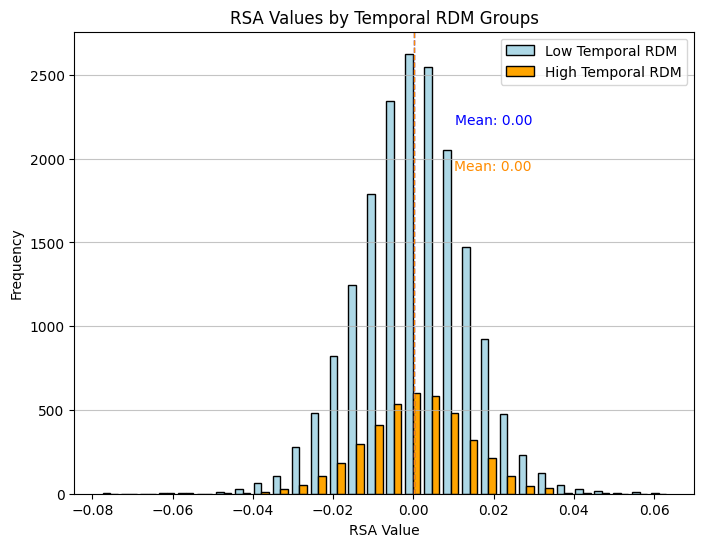

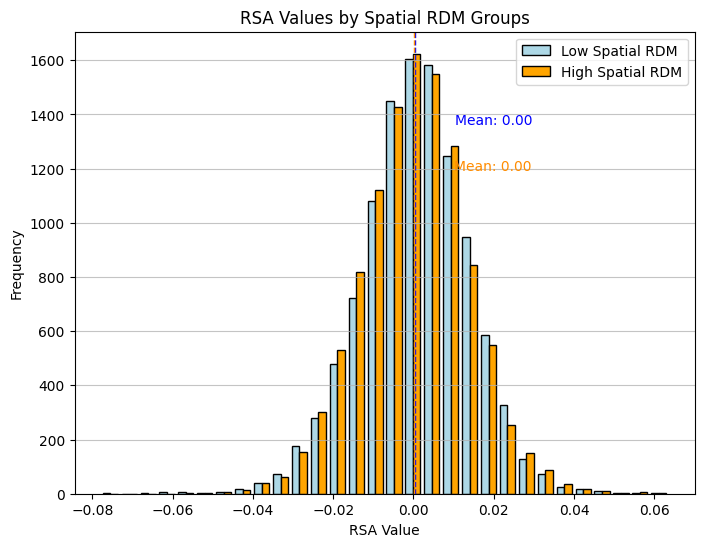

In [6]:
mean_low_temporal_rsa = np.mean(all_rsa_values[low_temporal_idxs])
mean_high_temporal_rsa = np.mean(all_rsa_values[high_temporal_idxs])
mean_low_spatial_rsa = np.mean(all_rsa_values[low_spatial_idxs])
mean_high_spatial_rsa = np.mean(all_rsa_values[high_spatial_idxs])

# Plot rsa values of low vs high temporal rdm values
plt.figure(figsize=(8, 6))
plt.hist([all_rsa_values[low_temporal_idxs], all_rsa_values[high_temporal_idxs]], 
         bins=30, color=['lightblue', 'orange'], edgecolor='black', label=['Low Temporal RDM', 'High Temporal RDM'])
# add mean lines
plt.axvline(mean_low_temporal_rsa, color='blue', linestyle='dashed', linewidth=1)
plt.axvline(mean_high_temporal_rsa, color='darkorange', linestyle='dashed', linewidth=1)
plt.text(mean_low_temporal_rsa + 0.01, plt.ylim()[1] * 0.8, f'Mean: {mean_low_temporal_rsa:.2f}', color='blue')
plt.text(mean_high_temporal_rsa + 0.01, plt.ylim()[1] * 0.7, f'Mean: {mean_high_temporal_rsa:.2f}', color='darkorange')
plt.title('RSA Values by Temporal RDM Groups')
plt.xlabel('RSA Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()
# Plot rsa values of low vs high spatial rdm values
plt.figure(figsize=(8, 6))
plt.hist([all_rsa_values[low_spatial_idxs], all_rsa_values[high_spatial_idxs]], 
         bins=30, color=['lightblue', 'orange'], edgecolor='black', label=['Low Spatial RDM', 'High Spatial RDM'])
# add mean lines
plt.axvline(mean_low_spatial_rsa, color='blue', linestyle='dashed', linewidth=1)
plt.axvline(mean_high_spatial_rsa, color='darkorange', linestyle='dashed', linewidth=1)
plt.text(mean_low_spatial_rsa + 0.01, plt.ylim()[1] * 0.8, f'Mean: {mean_low_spatial_rsa:.2f}', color='blue')
plt.text(mean_high_spatial_rsa + 0.01, plt.ylim()[1] * 0.7, f'Mean: {mean_high_spatial_rsa:.2f}', color='darkorange')
plt.title('RSA Values by Spatial RDM Groups')
plt.xlabel('RSA Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()